In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf


DATA_PATH = Path("DS0001") / "38304-0001-Data.tsv"
df = pd.read_csv(DATA_PATH, sep="\t")

print(f"Loaded {len(df):,} rows")

Loaded 1,495 rows


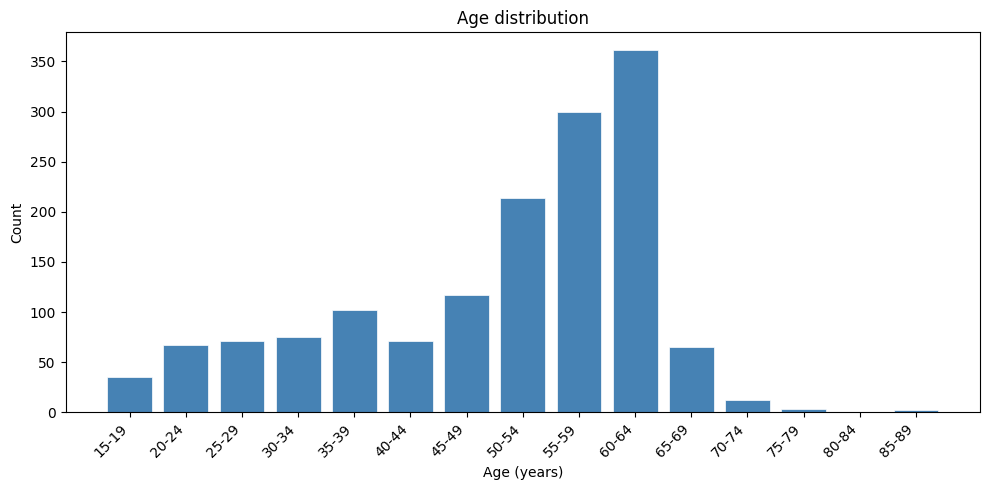

In [2]:
# Age distribution as a bar chart (5-year bins)
age = pd.to_numeric(df["AGE"], errors="coerce").dropna()
bin_edges = range(int(age.min() // 5 * 5), int(age.max() // 5 * 5) + 10, 5)
labels = [f"{lo}-{lo + 4}" for lo in bin_edges[:-1]]
binned = pd.cut(age, bins=list(bin_edges), right=False, labels=labels)
counts = binned.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
ax.set_title("Age distribution")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

In [5]:
# --- Steps 1–4: Positive well-being index (higher = better well-being) ---
# Negative-oriented raw items: reverse-code so higher = better.
# Scales from data: WHO26, SBQ_1, MISSSF_1, LONELINESS_*; positives: WELLNESS_1, WHO19, WELLNESS_25.

def reverse_1_k(x: pd.Series, k: int) -> pd.Series:
    """Map 1..k -> k..1 (missing preserved)."""
    v = pd.to_numeric(x, errors="coerce")
    out = (k + 1) - v
    return out.where(v.notna() & v.between(1, k, inclusive="both"))


# Step 1: pull items
neg_raw = pd.DataFrame(
    {
        "WHO26_rev": reverse_1_k(df["WHO26"], 5),
        "SBQ_1_rev": reverse_1_k(df["SBQ_1"], 6),
        "MISSSF_1_rev": reverse_1_k(df["MISSSF_1"], 10),
        "LONELINESS_1_rev": reverse_1_k(df["LONELINESS_1"], 3),
        "LONELINESS_2_rev": reverse_1_k(df["LONELINESS_2"], 3),
        "LONELINESS_3_rev": reverse_1_k(df["LONELINESS_3"], 3),
    }
)
pos_raw = pd.DataFrame(
    {
        "WELLNESS_1": pd.to_numeric(df["WELLNESS_1"], errors="coerce"),
        "WHO19": pd.to_numeric(df["WHO19"], errors="coerce"),
        "WELLNESS_25": pd.to_numeric(df["WELLNESS_25"], errors="coerce"),
    }
)

# Step 2–3: z-score each oriented item (sample SD); combine only complete rows for the index
oriented = pd.concat([neg_raw, pos_raw], axis=1)


def zscore(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    mu, sd = s.mean(), s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return s * np.nan
    return (s - mu) / sd


z_items = oriented.apply(zscore, axis=0)
# Step 4: mean of z-scores = composite (equal weight); require all 9 items (no partial means)
df["wellbeing_index_z"] = z_items.mean(axis=1, skipna=False)
df = df.copy()  # avoid fragmented frame after many column inserts
index_item_cols = list(z_items.columns)

print("Oriented items (after reverse-coding negatives):")
print(oriented.describe().T.round(3))
print("\nComposite (higher = better well-being), non-missing n:", df["wellbeing_index_z"].notna().sum())
print(df["wellbeing_index_z"].describe().round(4))



Oriented items (after reverse-coding negatives):
                   count   mean    std  min  25%  50%  75%   max
WHO26_rev         1495.0  3.728  0.987  1.0  3.0  4.0  4.0   5.0
SBQ_1_rev         1483.0  5.260  1.174  1.0  5.0  6.0  6.0   6.0
MISSSF_1_rev      1495.0  5.906  3.036  1.0  3.0  5.0  8.0  10.0
LONELINESS_1_rev  1495.0  2.386  0.701  1.0  2.0  3.0  3.0   3.0
LONELINESS_2_rev  1495.0  2.380  0.702  1.0  2.0  3.0  3.0   3.0
LONELINESS_3_rev  1495.0  2.348  0.732  1.0  2.0  3.0  3.0   3.0
WELLNESS_1        1495.0  3.723  1.042  1.0  3.0  4.0  4.0   5.0
WHO19             1495.0  3.766  1.050  1.0  3.0  4.0  5.0   5.0
WELLNESS_25       1495.0  3.765  0.989  1.0  3.0  4.0  4.0   5.0

Composite (higher = better well-being), non-missing n: 1483
count    1483.0000
mean        0.0006
std         0.6414
min        -2.2079
25%        -0.4015
50%         0.1016
75%         0.5063
max         1.0634
Name: wellbeing_index_z, dtype: float64


/var/folders/zl/vrkthn715j97ns3mht1gpfm80000gn/T/ipykernel_6577/321191813.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["wellbeing_index_z"] = z_items.mean(axis=1, skipna=False)


In [10]:
# --- Step 5: Cronbach's alpha (on z-scored index items; standardized alpha) ---

def cronbach_alpha(items: pd.DataFrame) -> float:
    items = items.dropna(how="any")
    k = items.shape[1]
    if k < 2 or len(items) < 2:
        return float("nan")
    item_vars = items.var(axis=0, ddof=1)
    total = items.sum(axis=1)
    total_var = total.var(ddof=1)
    if total_var == 0 or np.isnan(total_var):
        return float("nan")
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


alpha = cronbach_alpha(z_items)
print(f"Cronbach's alpha (standardized items, k={z_items.shape[1]}): {alpha:.3f}")


Cronbach's alpha (standardized items, k=9): 0.821


In [7]:
# --- Step 6: Regression predictors ---

survey_dt = pd.to_datetime(df["STARTDATE"], errors="coerce", format="mixed")
survey_year = survey_dt.dt.year
df["time_since_service_years"] = survey_year - pd.to_numeric(df["RETIRED"], errors="coerce")
df["CES_TOTAL"] = pd.to_numeric(df["CES_TOTAL"], errors="coerce")
df["RACE"] = pd.to_numeric(df["RACE"], errors="coerce")
df["INCOME"] = pd.to_numeric(df["INCOME"], errors="coerce")
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")

reg_cols = [
    "wellbeing_index_z",
    "CES_TOTAL",
    "RACE", 
    "INCOME",
    "time_since_service_years",
    "AGE",
]
reg_df = df.dropna(subset=reg_cols).copy()
print(f"Regression complete-case n: {len(reg_df):,}")

# Example: combat × race on well-being (HC1 robust SEs)
fit = smf.ols(
    "wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + time_since_service_years + AGE",
    data=reg_df,
).fit(cov_type="HC1")
print(fit.summary())



Regression complete-case n: 1,483
                            OLS Regression Results                            
Dep. Variable:      wellbeing_index_z   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     11.42
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           2.43e-25
Time:                        07:37:43   Log-Likelihood:                -1374.8
No. Observations:                1483   AIC:                             2780.
Df Residuals:                    1468   BIC:                             2859.
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Younger ppl

In [ ]:
# --- Step 6: Regression predictors ---

survey_dt = pd.to_datetime(df["STARTDATE"], errors="coerce", format="mixed")
survey_year = survey_dt.dt.year
df["time_since_service_years"] = survey_year - pd.to_numeric(df["RETIRED"], errors="coerce")
df["CES_TOTAL"] = pd.to_numeric(df["CES_TOTAL"], errors="coerce")
df["RACE"] = pd.to_numeric(df["RACE"], errors="coerce")
df["INCOME"] = pd.to_numeric(df["INCOME"], errors="coerce")
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")
df = df[df["AGE"] < 50].copy()
reg_cols = [
    "wellbeing_index_z",
    "CES_TOTAL",
    "RACE", 
    "INCOME",
    "time_since_service_years",
    "AGE",
]
reg_df = df.dropna(subset=reg_cols).copy()
print(f"Regression complete-case n: {len(reg_df):,}")

# Example: combat × race on well-being (HC1 robust SEs)
fit = smf.ols(
    "wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + time_since_service_years + AGE",
    data=reg_df,
).fit(cov_type="HC1")
print(fit.summary())



Regression complete-case n: 530
                            OLS Regression Results                            
Dep. Variable:      wellbeing_index_z   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     2.120
Date:                Fri, 24 Apr 2026   Prob (F-statistic):            0.00986
Time:                        15:16:09   Log-Likelihood:                -494.92
No. Observations:                 530   AIC:                             1020.
Df Residuals:                     515   BIC:                             1084.
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [11]:
# --- Nested model comparison: Age vs. multicollinearity with time_since_service_years ---
# Uses `reg_df` from the cells above (re-run those first so the sample matches your last regression).

formula_a = "wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + time_since_service_years + AGE"
formula_b = "wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + AGE"

fit_a = smf.ols(formula_a, data=reg_df).fit(cov_type="HC1")
fit_b = smf.ols(formula_b, data=reg_df).fit(cov_type="HC1")

print("Model A (full):", formula_a)
print("Model B (drop time_since_service_years):", formula_b)
print(f"N = {len(reg_df):,}\n")

print("--- Age coefficient ---")
print("Model A  AGE coef:", fit_a.params["AGE"], "  P-value:", fit_a.pvalues["AGE"])
print("Model B  AGE coef:", fit_b.params["AGE"], "  P-value:", fit_b.pvalues["AGE"])

print("\n--- Fit (nested: B inside A) ---")
print(f"Model A  R-squared: {fit_a.rsquared:.4f}  Adj. R-squared: {fit_a.rsquared_adj:.4f}  AIC: {fit_a.aic:.1f}")
print(f"Model B  R-squared: {fit_b.rsquared:.4f}  Adj. R-squared: {fit_b.rsquared_adj:.4f}  AIC: {fit_b.aic:.1f}")

# Likelihood-ratio test (note: invalid under heteroskedasticity; statsmodels warns if using HC1)
lr_stat, p_lr, df_diff = fit_a.compare_lr_test(fit_b)
print(f"\nLR test (A vs B, H0: time_since coef == 0): chi2({df_diff:.0f}) = {lr_stat:.4f}, p = {p_lr:.4f}")

# Classical nested F-test (homoskedastic OLS) — valid comparison for nested models here
from scipy.stats import f as f_distribution

fit_a_ml = smf.ols(formula_a, data=reg_df).fit()
fit_b_ml = smf.ols(formula_b, data=reg_df).fit()
q = int(round(fit_a_ml.df_model - fit_b_ml.df_model))
F_stat = ((fit_b_ml.ssr - fit_a_ml.ssr) / q) / (fit_a_ml.ssr / fit_a_ml.df_resid)
p_f = float(f_distribution.sf(F_stat, q, fit_a_ml.df_resid))
print(
    f"\nNested F-test (classical OLS): F({q},{fit_a_ml.df_resid:.0f}) = {F_stat:.4f}, p = {p_f:.4f}"
)



Model A (full): wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + time_since_service_years + AGE
Model B (drop time_since_service_years): wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + AGE
N = 1,483

--- Age coefficient ---
Model A  AGE coef: 0.012148343449520451   P-value: 5.410690246750279e-13
Model B  AGE coef: 0.010993418591937136   P-value: 1.2341571530023277e-16

--- Fit (nested: B inside A) ---
Model A  R-squared: 0.0905  Adj. R-squared: 0.0818  AIC: 2779.7
Model B  R-squared: 0.0897  Adj. R-squared: 0.0817  AIC: 2778.9

LR test (A vs B, H0: time_since coef == 0): chi2(1) = 1.2343, p = 0.2666

Nested F-test (classical OLS): F(1,1468) = 1.2223, p = 0.2691


/Users/katherineharvey/anaconda3/envs/test/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:2376: InvalidTestWarning: Likelihood Ratio test is likely invalid with robust covariance, proceeding anyway
  warnings.warn('Likelihood Ratio test is likely invalid with ' +


In [12]:
# --- Combat exposure × Age (interaction) ---
# Does the association between CES_TOTAL and well-being change with age?
# Uses current `df` from cells above (re-run those first; any filter such as AGE < 50 still applies).

_int_cols = ["wellbeing_index_z", "CES_TOTAL", "AGE", "RACE", "INCOME"]
_reg_ces_age = df.dropna(subset=_int_cols).copy()
print(f"Complete-case n: {len(_reg_ces_age):,}")

fit_ces_age = smf.ols(
    "wellbeing_index_z ~ CES_TOTAL * AGE + C(RACE) + INCOME",
    data=_reg_ces_age,
).fit(cov_type="HC1")
print(fit_ces_age.summary())



Complete-case n: 1,483
                            OLS Regression Results                            
Dep. Variable:      wellbeing_index_z   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     16.88
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           9.87e-27
Time:                        08:35:04   Log-Likelihood:                -1377.7
No. Observations:                1483   AIC:                             2775.
Df Residuals:                    1473   BIC:                             2828.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.604

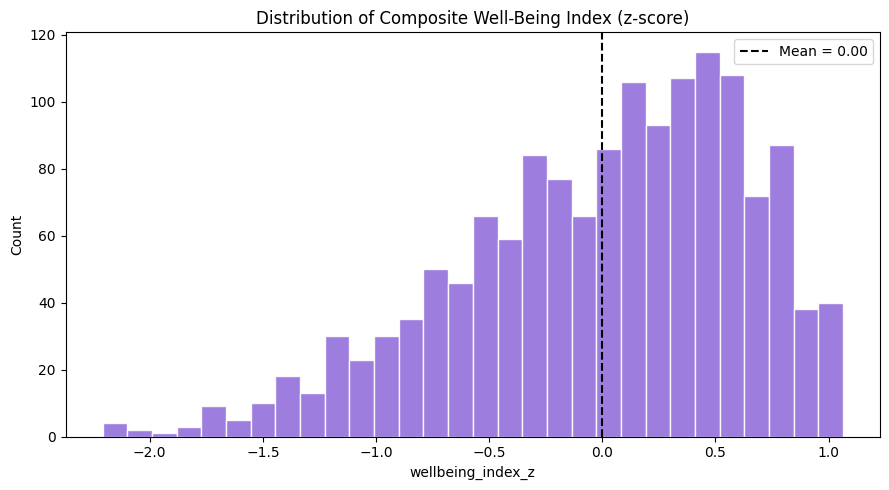

count    1483.0000
mean        0.0006
std         0.6414
min        -2.2079
25%        -0.4015
50%         0.1016
75%         0.5063
max         1.0634
Name: wellbeing_index_z, dtype: float64


In [9]:
# Histogram of composite well-being scores
# Run after the index-construction cell so `wellbeing_index_z` exists.

scores = df["wellbeing_index_z"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(scores, bins=30, color="mediumpurple", edgecolor="white", alpha=0.9)
ax.axvline(scores.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean = {scores.mean():.2f}")

ax.set_title("Distribution of Composite Well-Being Index (z-score)")
ax.set_xlabel("wellbeing_index_z")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()

print(scores.describe().round(4))

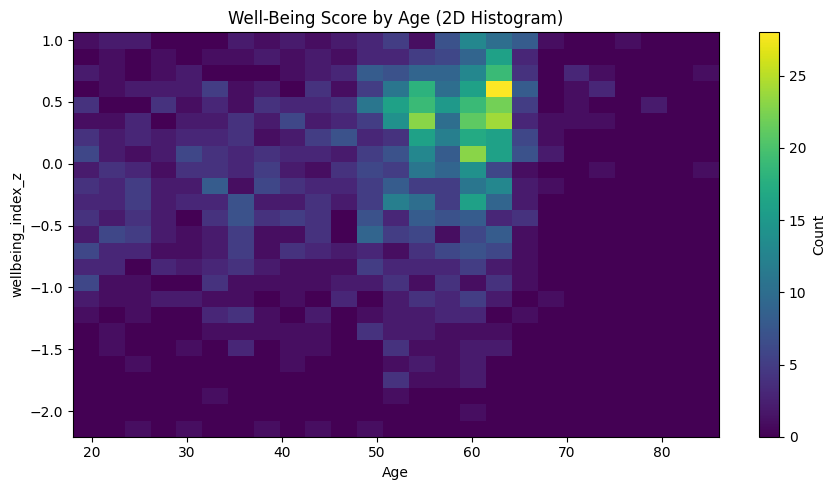

Rows used: 1,483


In [13]:
# 2D histogram: well-being score over age
_plot_age = df.copy()
_plot_age["AGE"] = pd.to_numeric(_plot_age["AGE"], errors="coerce")
_plot_age["wellbeing_index_z"] = pd.to_numeric(_plot_age["wellbeing_index_z"], errors="coerce")
_age_data = _plot_age[["AGE", "wellbeing_index_z"]].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
h = ax.hist2d(
    _age_data["AGE"],
    _age_data["wellbeing_index_z"],
    bins=[25, 25],
    cmap="viridis",
)

cbar = fig.colorbar(h[3], ax=ax)
cbar.set_label("Count")
ax.set_title("Well-Being Score by Age (2D Histogram)")
ax.set_xlabel("Age")
ax.set_ylabel("wellbeing_index_z")
fig.tight_layout()
plt.show()

print(f"Rows used: {len(_age_data):,}")

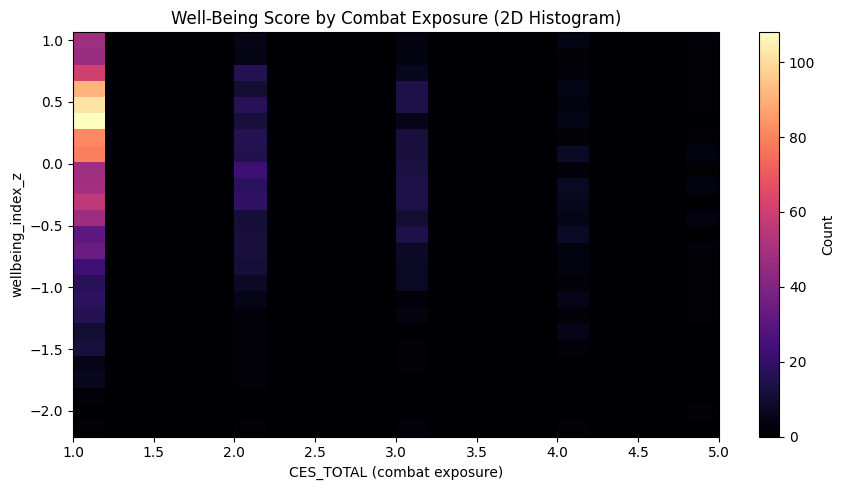

Rows used: 1,483


In [14]:
# 2D histogram: well-being score over combat exposure
_plot_combat = df.copy()
_plot_combat["CES_TOTAL"] = pd.to_numeric(_plot_combat["CES_TOTAL"], errors="coerce")
_plot_combat["wellbeing_index_z"] = pd.to_numeric(_plot_combat["wellbeing_index_z"], errors="coerce")
_combat_data = _plot_combat[["CES_TOTAL", "wellbeing_index_z"]].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
h = ax.hist2d(
    _combat_data["CES_TOTAL"],
    _combat_data["wellbeing_index_z"],
    bins=[20, 25],
    cmap="magma",
)

cbar = fig.colorbar(h[3], ax=ax)
cbar.set_label("Count")
ax.set_title("Well-Being Score by Combat Exposure (2D Histogram)")
ax.set_xlabel("CES_TOTAL (combat exposure)")
ax.set_ylabel("wellbeing_index_z")
fig.tight_layout()
plt.show()

print(f"Rows used: {len(_combat_data):,}")

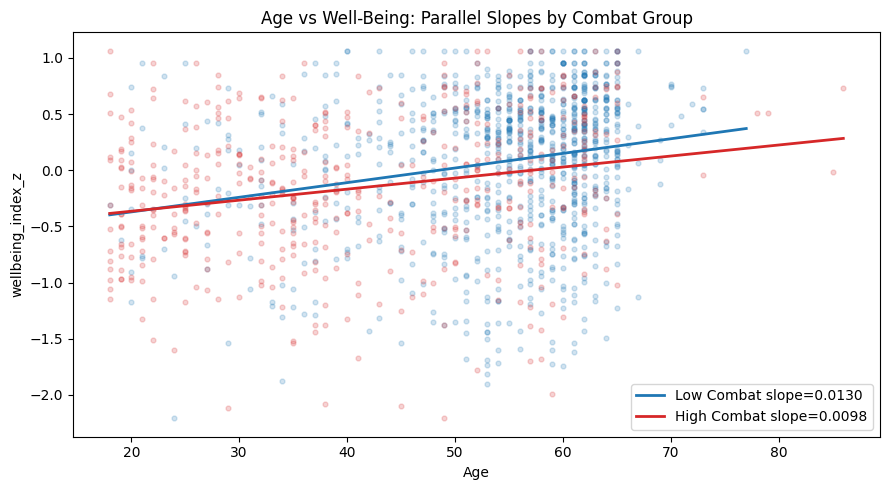

CES_TOTAL cutpoints: q25=1.00, q75=2.00
combat_group
Low Combat     991
High Combat    492
Name: count, dtype: int64


In [19]:
# Parallel Slopes Plot: Age × Combat (Low vs High Combat groups)
import numpy as np
import statsmodels.formula.api as smf

_ps = df.copy()
_ps["AGE"] = pd.to_numeric(_ps["AGE"], errors="coerce")
_ps["CES_TOTAL"] = pd.to_numeric(_ps["CES_TOTAL"], errors="coerce")
_ps["wellbeing_index_z"] = pd.to_numeric(_ps["wellbeing_index_z"], errors="coerce")
_ps = _ps[["AGE", "CES_TOTAL", "wellbeing_index_z"]].dropna()

if _ps.empty:
    print("No rows available after dropna for AGE, CES_TOTAL, wellbeing_index_z. Run index-construction cells first.")
else:
    # Split combat exposure using quartiles (bottom 25% = Low, top 25% = High).
    # This avoids empty groups when CES_TOTAL is heavily concentrated at low values.
    q25 = _ps["CES_TOTAL"].quantile(0.25)
    q75 = _ps["CES_TOTAL"].quantile(0.75)

    low = _ps[_ps["CES_TOTAL"] <= q25].copy()
    high = _ps[_ps["CES_TOTAL"] >= q75].copy()
    _ps2 = pd.concat([low.assign(combat_group="Low Combat"), high.assign(combat_group="High Combat")], axis=0)

    fig, ax = plt.subplots(figsize=(9, 5))

    plotted_groups = 0
    for grp, color in [("Low Combat", "tab:blue"), ("High Combat", "tab:red")]:
        g = _ps2[_ps2["combat_group"] == grp]
        if len(g) < 2 or g["AGE"].nunique() < 2:
            print(f"Skipping {grp}: not enough data for regression line (n={len(g)}).")
            continue

        fit_g = smf.ols("wellbeing_index_z ~ AGE", data=g).fit()

        # scatter + fitted line
        ax.scatter(g["AGE"], g["wellbeing_index_z"], s=12, alpha=0.2, color=color)
        x_grid = np.linspace(g["AGE"].min(), g["AGE"].max(), 100)
        y_hat = fit_g.params["Intercept"] + fit_g.params["AGE"] * x_grid
        ax.plot(x_grid, y_hat, color=color, linewidth=2, label=f"{grp} slope={fit_g.params['AGE']:.4f}")
        plotted_groups += 1

    if plotted_groups == 0:
        print("No group had enough variation to fit AGE slopes.")
    else:
        ax.set_title("Age vs Well-Being: Parallel Slopes by Combat Group")
        ax.set_xlabel("Age")
        ax.set_ylabel("wellbeing_index_z")
        ax.legend()
        fig.tight_layout()
        plt.show()

    print(f"CES_TOTAL cutpoints: q25={q25:.2f}, q75={q75:.2f}")
    print(_ps2["combat_group"].value_counts())

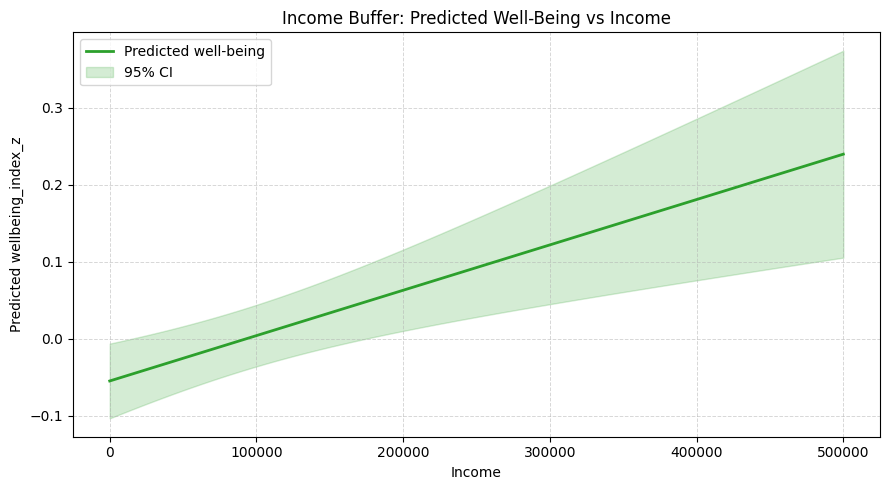

Reference profile: RACE=1, CES_TOTAL=1.60, AGE=50.14
Income slope estimate: 0.00000059 (p=0.0002158)


In [27]:
# Income Buffer Marginal Effects Plot
import numpy as np
import statsmodels.formula.api as smf

_me = df.copy()
for c in ["wellbeing_index_z", "CES_TOTAL", "RACE", "INCOME", "AGE"]:
    _me[c] = pd.to_numeric(_me[c], errors="coerce")
_me = _me[["wellbeing_index_z", "CES_TOTAL", "RACE", "INCOME", "AGE"]].dropna()

if _me.empty:
    print("No rows available for income marginal-effects model. Run index-construction cells first.")
else:
    # Fit your interaction model, then vary income while holding other predictors at typical values.
    fit_me = smf.ols(
        "wellbeing_index_z ~ CES_TOTAL * AGE + C(RACE) + INCOME",
        data=_me,
    ).fit(cov_type="HC1")

    income_grid = np.linspace(_me["INCOME"].quantile(0.01), _me["INCOME"].quantile(0.99), 100)
    ref_race = int(_me["RACE"].mode().iloc[0])
    ref_ces = float(_me["CES_TOTAL"].mean())
    ref_age = float(_me["AGE"].mean())

    pred_df = pd.DataFrame(
        {
            "INCOME": income_grid,
            "CES_TOTAL": ref_ces,
            "AGE": ref_age,
            "RACE": ref_race,
        }
    )

    pred = fit_me.get_prediction(pred_df).summary_frame(alpha=0.05)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(income_grid, pred["mean"], color="tab:green", linewidth=2, label="Predicted well-being")
    ax.fill_between(income_grid, pred["mean_ci_lower"], pred["mean_ci_upper"], color="tab:green", alpha=0.2, label="95% CI")

    ax.set_title("Income Buffer: Predicted Well-Being vs Income")
    ax.set_xlabel("Income")
    ax.set_ylabel("Predicted wellbeing_index_z")
    ax.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.legend()
    fig.tight_layout()
    plt.show()

    print(f"Reference profile: RACE={ref_race}, CES_TOTAL={ref_ces:.2f}, AGE={ref_age:.2f}")
    print(f"Income slope estimate: {fit_me.params['INCOME']:.8f} (p={fit_me.pvalues['INCOME']:.4g})")

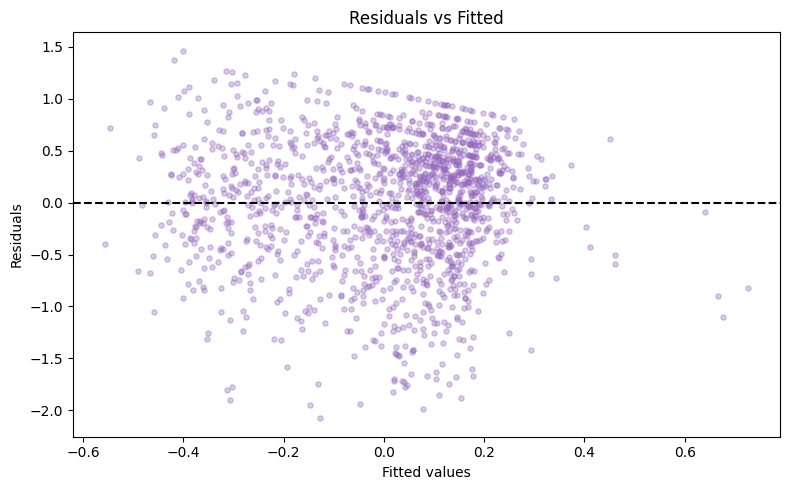

N used: 1,483
A random cloud around 0 with no strong curve/funnel pattern supports model adequacy.


In [21]:
# Residuals vs Fitted (model diagnostics / honesty check)
import statsmodels.formula.api as smf

_diag = df.copy()
for c in ["wellbeing_index_z", "CES_TOTAL", "RACE", "INCOME", "AGE"]:
    _diag[c] = pd.to_numeric(_diag[c], errors="coerce")
_diag = _diag[["wellbeing_index_z", "CES_TOTAL", "RACE", "INCOME", "AGE"]].dropna()

if _diag.empty:
    print("No rows available for residual diagnostics. Run index-construction cells first.")
else:
    fit_diag = smf.ols(
        "wellbeing_index_z ~ CES_TOTAL * AGE + C(RACE) + INCOME",
        data=_diag,
    ).fit(cov_type="HC1")

    fitted = fit_diag.fittedvalues
    resid = fit_diag.resid

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(fitted, resid, s=14, alpha=0.35, color="tab:purple")
    ax.axhline(0, color="black", linestyle="--", linewidth=1.5)

    ax.set_title("Residuals vs Fitted")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    fig.tight_layout()
    plt.show()

    print(f"N used: {len(_diag):,}")
    print("A random cloud around 0 with no strong curve/funnel pattern supports model adequacy.")

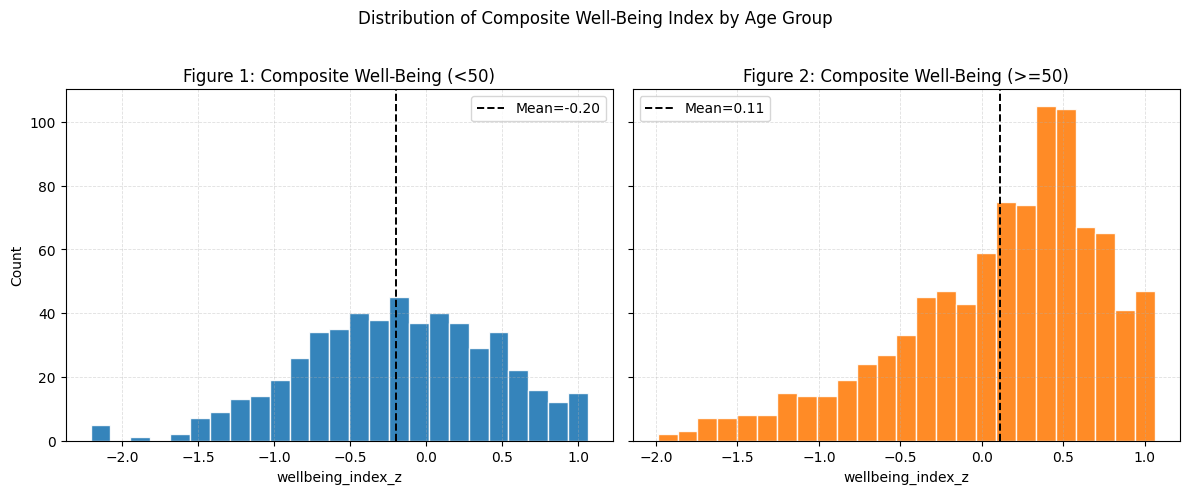

N < 50: 530
N >= 50: 953


In [22]:
# Figure 1-2: Distribution of composite well-being index by age group (<50 vs >=50)
_dist = df.copy()
_dist["AGE"] = pd.to_numeric(_dist["AGE"], errors="coerce")
_dist["wellbeing_index_z"] = pd.to_numeric(_dist["wellbeing_index_z"], errors="coerce")
_dist = _dist[["AGE", "wellbeing_index_z"]].dropna()

under_50 = _dist[_dist["AGE"] < 50]["wellbeing_index_z"]
over_50 = _dist[_dist["AGE"] >= 50]["wellbeing_index_z"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

axes[0].hist(under_50, bins=25, color="tab:blue", edgecolor="white", alpha=0.9)
axes[0].axvline(under_50.mean(), color="black", linestyle="--", linewidth=1.4, label=f"Mean={under_50.mean():.2f}")
axes[0].set_title("Figure 1: Composite Well-Being (<50)")
axes[0].set_xlabel("wellbeing_index_z")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
axes[0].legend()

axes[1].hist(over_50, bins=25, color="tab:orange", edgecolor="white", alpha=0.9)
axes[1].axvline(over_50.mean(), color="black", linestyle="--", linewidth=1.4, label=f"Mean={over_50.mean():.2f}")
axes[1].set_title("Figure 2: Composite Well-Being (>=50)")
axes[1].set_xlabel("wellbeing_index_z")
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
axes[1].legend()

fig.suptitle("Distribution of Composite Well-Being Index by Age Group", y=1.02)
fig.tight_layout()
plt.show()

print(f"N < 50: {len(under_50):,}")
print(f"N >= 50: {len(over_50):,}")

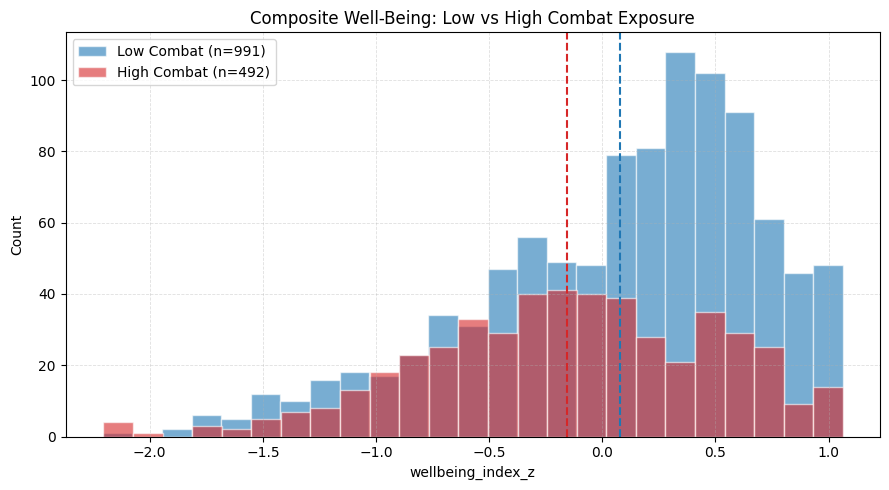

Combat cutpoints: q25=1.00, q75=2.00


In [24]:
# Standalone figure: Composite well-being distribution for low vs high combat exposure
_combat = df.copy()
for c in ["wellbeing_index_z", "CES_TOTAL"]:
    _combat[c] = pd.to_numeric(_combat[c], errors="coerce")
_combat = _combat[["wellbeing_index_z", "CES_TOTAL"]].dropna()

q25 = _combat["CES_TOTAL"].quantile(0.25)
q75 = _combat["CES_TOTAL"].quantile(0.75)
low_combat = _combat[_combat["CES_TOTAL"] <= q25]["wellbeing_index_z"]
high_combat = _combat[_combat["CES_TOTAL"] >= q75]["wellbeing_index_z"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(low_combat, bins=25, alpha=0.6, color="tab:blue", edgecolor="white", label=f"Low Combat (n={len(low_combat):,})")
ax.hist(high_combat, bins=25, alpha=0.6, color="tab:red", edgecolor="white", label=f"High Combat (n={len(high_combat):,})")
ax.axvline(low_combat.mean(), color="tab:blue", linestyle="--", linewidth=1.5)
ax.axvline(high_combat.mean(), color="tab:red", linestyle="--", linewidth=1.5)

ax.set_title("Composite Well-Being: Low vs High Combat Exposure")
ax.set_xlabel("wellbeing_index_z")
ax.set_ylabel("Count")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

print(f"Combat cutpoints: q25={q25:.2f}, q75={q75:.2f}")

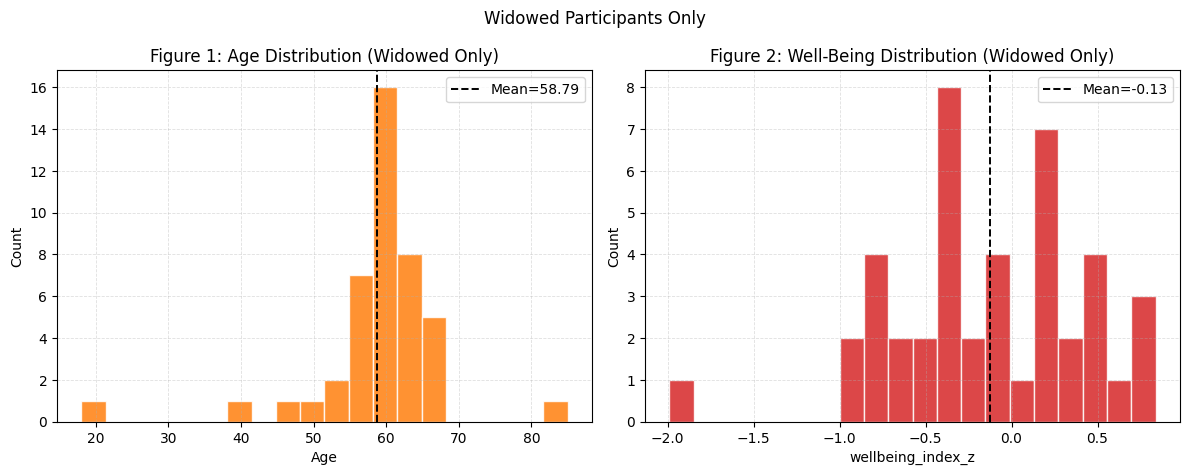

Widowed sample size (AGE non-missing): 43
Widowed sample size (wellbeing non-missing): 43


In [36]:
# Figure 1-2: Widowed-only distributions (Age and Composite Well-Being)
_w_only = df.copy()
_w_only["AGE"] = pd.to_numeric(_w_only["AGE"], errors="coerce")
_w_only["MARITAL"] = pd.to_numeric(_w_only["MARITAL"], errors="coerce")
_w_only["wellbeing_index_z"] = pd.to_numeric(_w_only["wellbeing_index_z"], errors="coerce")

# Widowed only (MARITAL == 5)
_w_only = _w_only[_w_only["MARITAL"] == 5].copy()

age_w = _w_only["AGE"].dropna()
wb_w = _w_only["wellbeing_index_z"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Figure 1: Age distribution (widowed only)
axes[0].hist(age_w, bins=20, color="tab:orange", edgecolor="white", alpha=0.85)
axes[0].axvline(age_w.mean(), color="black", linestyle="--", linewidth=1.4, label=f"Mean={age_w.mean():.2f}")
axes[0].set_title("Figure 1: Age Distribution (Widowed Only)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
axes[0].legend()

# Figure 2: Well-being distribution (widowed only)
axes[1].hist(wb_w, bins=20, color="tab:red", edgecolor="white", alpha=0.85)
axes[1].axvline(wb_w.mean(), color="black", linestyle="--", linewidth=1.4, label=f"Mean={wb_w.mean():.2f}")
axes[1].set_title("Figure 2: Well-Being Distribution (Widowed Only)")
axes[1].set_xlabel("wellbeing_index_z")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
axes[1].legend()

fig.suptitle("Widowed Participants Only", y=0.98)
fig.tight_layout()
plt.show()

print(f"Widowed sample size (AGE non-missing): {len(age_w):,}")
print(f"Widowed sample size (wellbeing non-missing): {len(wb_w):,}")

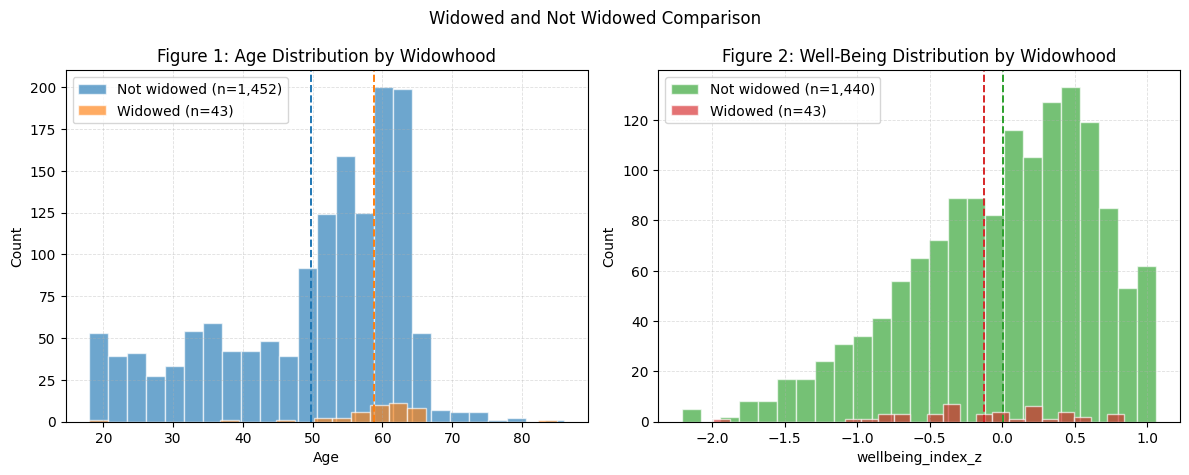

Age means:
  Not widowed: 49.79
  Widowed:     58.79

Well-being means:
  Not widowed: 0.004
  Widowed:     -0.128


In [35]:
# Figure 1-2: Widowed vs Not Widowed in one figure (Age + Composite Well-Being)
_wb = df.copy()
_wb["AGE"] = pd.to_numeric(_wb["AGE"], errors="coerce")
_wb["MARITAL"] = pd.to_numeric(_wb["MARITAL"], errors="coerce")
_wb["wellbeing_index_z"] = pd.to_numeric(_wb["wellbeing_index_z"], errors="coerce")
_wb["widowed"] = (_wb["MARITAL"] == 5).astype(int)

# Data slices
age_not_w = _wb.loc[_wb["widowed"] == 0, "AGE"].dropna()
age_w = _wb.loc[_wb["widowed"] == 1, "AGE"].dropna()
wb_not_w = _wb.loc[_wb["widowed"] == 0, "wellbeing_index_z"].dropna()
wb_w = _wb.loc[_wb["widowed"] == 1, "wellbeing_index_z"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Figure 1: Age distribution
axes[0].hist(age_not_w, bins=25, alpha=0.65, color="tab:blue", edgecolor="white", label=f"Not widowed (n={len(age_not_w):,})")
axes[0].hist(age_w, bins=25, alpha=0.65, color="tab:orange", edgecolor="white", label=f"Widowed (n={len(age_w):,})")
axes[0].axvline(age_not_w.mean(), color="tab:blue", linestyle="--", linewidth=1.4)
axes[0].axvline(age_w.mean(), color="tab:orange", linestyle="--", linewidth=1.4)
axes[0].set_title("Figure 1: Age Distribution by Widowhood")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
axes[0].legend()

# Figure 2: Composite well-being distribution
axes[1].hist(wb_not_w, bins=25, alpha=0.65, color="tab:green", edgecolor="white", label=f"Not widowed (n={len(wb_not_w):,})")
axes[1].hist(wb_w, bins=25, alpha=0.65, color="tab:red", edgecolor="white", label=f"Widowed (n={len(wb_w):,})")
axes[1].axvline(wb_not_w.mean(), color="tab:green", linestyle="--", linewidth=1.4)
axes[1].axvline(wb_w.mean(), color="tab:red", linestyle="--", linewidth=1.4)
axes[1].set_title("Figure 2: Well-Being Distribution by Widowhood")
axes[1].set_xlabel("wellbeing_index_z")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
axes[1].legend()

fig.suptitle("Widowed and Not Widowed Comparison", y=0.98)
fig.tight_layout()
plt.show()

print("Age means:")
print(f"  Not widowed: {age_not_w.mean():.2f}")
print(f"  Widowed:     {age_w.mean():.2f}")
print("\nWell-being means:")
print(f"  Not widowed: {wb_not_w.mean():.3f}")
print(f"  Widowed:     {wb_w.mean():.3f}")